<a href="https://colab.research.google.com/github/gabrielcggs/CP02-SERS-MACHINE-LEARNING/blob/main/CP2_SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PREPARAÇÃO AMBIENTE

In [77]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learnng
# Algoritmos do sklearn para Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Algoritmos do sklearn para Regressão
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Separação os dados de treino e teste
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test

# Métrica de avaliação para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

#Métricas de avaliação import
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.metrics import classification_report # resumo de métricas

## Tarefa 1 — Classificação (ANEEL)

In [78]:
dados = pd.read_csv("/content/aneel_classificacao_orange.csv")

In [79]:
dados.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


##ANÁLISE

In [80]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [81]:
# Somente estatísticas de atributos categóricos
dados.describe(include = 'object')

,fonte
count,3876
unique,3
top,Hidráulica
freq,1476


In [82]:
# somente estatísticas de atributos númericos
dados.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


In [83]:
# Checando a quantidade de classes da coluna alvo (fonte)
dados['fonte'].unique()

array(['Solar', 'Eólica', 'Hidráulica'], dtype=object)

In [84]:
# Checando a quantidade de valores de cada classe da coluna alvo (stabf)
dados['fonte'].value_counts()


,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


## Separação de dados:
 Entrada (features) -----> X

 Saída(target) -----> y


In [85]:
#Features
X = dados.drop(['fonte'], axis = 1)
X.head()

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000


In [86]:
# Variável alvo(target)
y = dados['fonte']
y.head()

,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


## Separação de dados de treino e teste

In [87]:
X_train, X_teste, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 17)

In [88]:
X.shape

(3876, 3)

In [89]:
X_train.shape # 80% dos dados para treino

(3100, 3)

In [90]:
X_teste.shape # 20% dos dados para teste

(776, 3)

##Treinamento de modelos usando 3 algoritmos para classificação diferentes

In [91]:
# Instanciando o modelo
modelo_LR = LogisticRegression()
# Treinando o modelo
modelo_LR.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [92]:
# Instanciando o modelo
modelo_RFC = RandomForestClassifier()
# Treinando o modelo
modelo_RFC.fit(X_train, y_train)

RandomForestClassifier()

In [93]:
# Instanciando o modelo
modelo_KNC = KNeighborsClassifier()
# Treinando o modelo
modelo_KNC.fit(X_train, y_train)

KNeighborsClassifier()

GERANDO PREVISÕES

In [94]:
y_predictLR = modelo_LR.predict(X_teste)
y_predictLR

array(['Solar', 'Solar', 'Hidráulica', 'Hidráulica', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Eólica',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Solar', 'Hidráulica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar', 'Solar', 'Solar',
       'Eólica', 'Eólica', 'Eólica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Eólica',
       'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar', 'Eólica',
       'Solar', 'Solar', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Eólica', 'Eólica', 'Solar', 'Hidráulica', 'Solar', 'Solar',
       'Solar', 'Hidráulica', 'Hidráulica', 'Solar', 'Solar', 'Eólica',
       'Hidráulica', 'So

In [95]:
y_predictRFC = modelo_RFC.predict(X_teste)
y_predictRFC

array(['Solar', 'Solar', 'Hidráulica', 'Solar', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar', 'Solar', 'Solar',
       'Solar', 'Eólica', 'Eólica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar',
       'Solar', 'Hidráulica', 'Eólica', 'Solar', 'Eólica', 'Eólica',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Hidráulica', 'Eólica',
       'Solar', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Solar', 'Eólica', 'Hidráulica',
       'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica', 'Hidráulica',
       'Eólica', 'Eólica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Solar',
       'Hid

In [96]:
y_predictKNC = modelo_KNC.predict(X_teste)
y_predictKNC

array(['Solar', 'Solar', 'Hidráulica', 'Solar', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar',
       'Hidráulica', 'Solar', 'Solar', 'Solar', 'Eólica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar',
       'Solar', 'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Solar', 'Eólica', 'Hidráulica',
       'Eólica', 'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Eólica', 'Eólica',
       'Eólica', 'Eólica', 'Solar', 'Hidráulica', 'Hidráulica', 'Eólica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Eólica',
       'Hidráulica', 'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', '

## Avaliação do modelo - utilizando a média weighted avarage

In [97]:
# Acurácia
acuraciaLR = 100 * accuracy_score(y_test, y_predictLR)
print(f'A acurácia do modelo baseado em Regressão Logística é: {acuraciaLR:.2f}%')

acuraciaRFC = 100 * accuracy_score(y_test, y_predictRFC)
print(f'A acurácia do modelo baseado em RandomForestClassifier é: {acuraciaRFC:.2f}%')

acuraciaKNC = 100 * accuracy_score(y_test, y_predictKNC)
print(f'A acurácia do modelo baseado em KNeighborsClassifier é: {acuraciaKNC:.2f}%')

A acurácia do modelo baseado em Regressão Logística é: 71.13%
A acurácia do modelo baseado em RandomForestClassifier é: 97.81%
A acurácia do modelo baseado em KNeighborsClassifier é: 85.57%


In [98]:
# Precisao
precisaoLR = precision_score(y_test, y_predictLR, average='weighted')
print(f'A precisão do modelo baseado em Regressão Logística é: {precisaoLR:.2f}%')

precisaoRFC = precision_score(y_test, y_predictRFC, average='weighted')
print(f'A precisão do modelo baseado em RandomForestClassifier é: {precisaoRFC:.2f}%')

precisaoKNC = precision_score(y_test, y_predictKNC, average='weighted')
print(f'A precisão do modelo baseado em KNeighborsClassifier é: {precisaoKNC:.2f}%')



A precisão do modelo baseado em Regressão Logística é: 0.71%
A precisão do modelo baseado em RandomForestClassifier é: 0.98%
A precisão do modelo baseado em KNeighborsClassifier é: 0.86%


In [99]:
# Recall
recallLR = recall_score(y_test, y_predictLR, average='weighted')
print(f'O recall do modelo baseado em Regressão Logística é: {recallLR:.2f}%')

recallRFC =  recall_score(y_test, y_predictRFC, average='weighted')
print(f'O recall do modelo baseado em RandomForestClassifier é: {recallRFC:.2f}%')

recallKNC = recall_score(y_test, y_predictKNC, average='weighted')
print(f'O recall do modelo baseado em KNeighborsClassifier é: {recallKNC:.2f}%')

O recall do modelo baseado em Regressão Logística é: 0.71%
O recall do modelo baseado em RandomForestClassifier é: 0.98%
O recall do modelo baseado em KNeighborsClassifier é: 0.86%


In [100]:
# F1-Score
f1LR = f1_score(y_test, y_predictLR, average='weighted')
print(f'O F1-Score do modelo baseado em Regressão Logística é: {f1LR:.2f}%')

f1RFC =  f1_score(y_test, y_predictRFC, average='weighted')
print(f'O F1-Score do modelo baseado em RandomForestClassifier é: {f1RFC:.2f}%')

f1KNC = f1_score(y_test, y_predictKNC, average='weighted')
print(f'O F1-Score do modelo baseado em KNeighborsClassifier é: {f1KNC:.2f}%')

O F1-Score do modelo baseado em Regressão Logística é: 0.71%
O F1-Score do modelo baseado em RandomForestClassifier é: 0.98%
O F1-Score do modelo baseado em KNeighborsClassifier é: 0.86%


In [101]:
# classfication Report usando seaborn e matplolib
reportLR = classification_report(y_test, y_predictLR)
print(reportLR)

              precision    recall  f1-score   support

      Eólica       0.69      0.58      0.63       247
  Hidráulica       0.78      0.81      0.79       298
       Solar       0.65      0.73      0.69       231

    accuracy                           0.71       776
   macro avg       0.71      0.70      0.70       776
weighted avg       0.71      0.71      0.71       776



In [102]:
# classfication Report usando seaborn e matplolib
reportRFC = classification_report(y_test, y_predictRFC)
print(reportRFC)

              precision    recall  f1-score   support

      Eólica       0.98      0.97      0.97       247
  Hidráulica       0.98      0.99      0.98       298
       Solar       0.98      0.97      0.98       231

    accuracy                           0.98       776
   macro avg       0.98      0.98      0.98       776
weighted avg       0.98      0.98      0.98       776



In [103]:
# classfication Report usando seaborn e matplolib
reportKNC = classification_report(y_test, y_predictKNC)
print(reportKNC)

              precision    recall  f1-score   support

      Eólica       0.81      0.80      0.80       247
  Hidráulica       0.88      0.87      0.87       298
       Solar       0.87      0.90      0.89       231

    accuracy                           0.86       776
   macro avg       0.85      0.86      0.85       776
weighted avg       0.86      0.86      0.86       776



TABELA DE COMPARAÇÃO

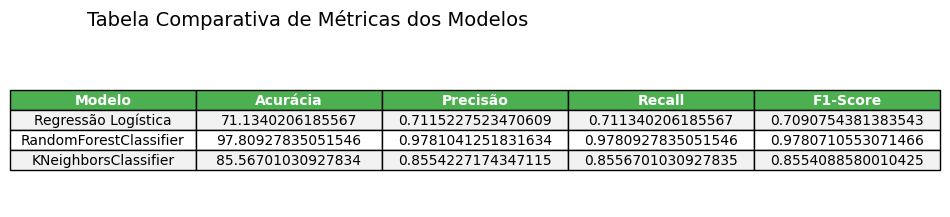

In [104]:
metricas = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'RandomForestClassifier', 'KNeighborsClassifier'],
    'Acurácia': [acuraciaLR, acuraciaRFC, acuraciaKNC],
    'Precisão': [precisaoLR, precisaoRFC, precisaoKNC],
    'Recall': [recallLR, recallRFC, recallKNC],
    'F1-Score': [f1LR, f1RFC, f1KNC]
})

fig, ax = plt.subplots(figsize=(10, 2)) # Adjust figure size as needed
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=metricas.values, colLabels=metricas.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2) # Adjust scale for better readability

# Style the header
for (i, j), cell in table.get_celld().items():
    if i == 0: # Header row
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4CAF50') # Green header background
    elif i > 0: # Body rows
        cell.set_facecolor('#f2f2f2' if (i-1) % 2 == 0 else 'white') # Alternate row colors

plt.title('Tabela Comparativa de Métricas dos Modelos', loc='left', fontsize=14, pad=20)
plt.show()

### Matrizes de Confusão

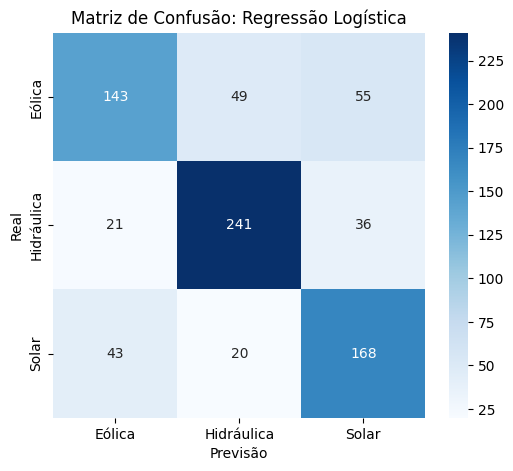

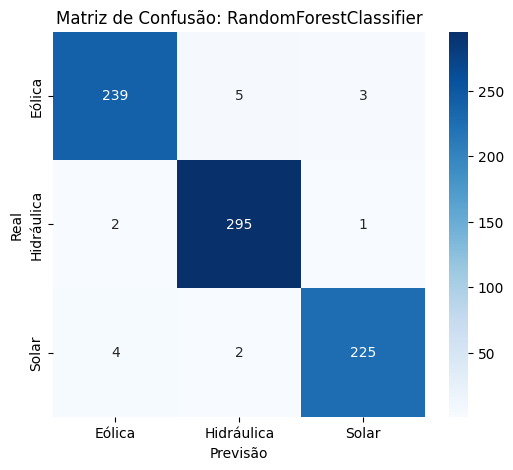

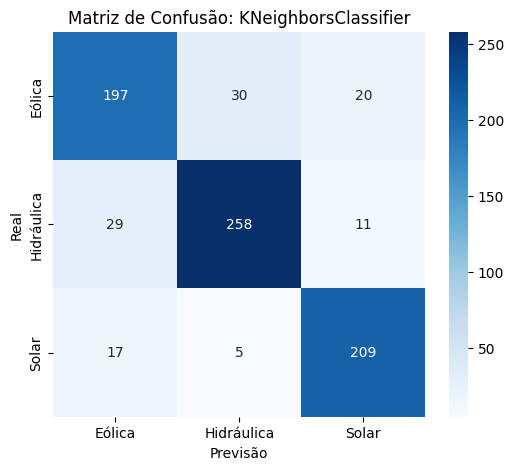

In [105]:
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Previsão')
    plt.ylabel('Real')
    plt.show()

labels = sorted(y.unique())

plot_confusion_matrix(y_test, y_predictLR, labels, 'Matriz de Confusão: Regressão Logística')
plot_confusion_matrix(y_test, y_predictRFC, labels, 'Matriz de Confusão: RandomForestClassifier')
plot_confusion_matrix(y_test, y_predictKNC, labels, 'Matriz de Confusão: KNeighborsClassifier')

### Interpretação dos Resultados

Com base na tabela comparativa de métricas e nas matrizes de confusão, podemos fazer as seguintes observações:

*   **Modelo Escolhido:** O **RandomForestClassifier** se destaca como o melhor modelo para este problema de classificação. Ele apresenta as maiores pontuações em todas as métricas (acurácia, precisão, recall e F1-Score), indicando que é o mais preciso e robusto na identificação das fontes de energia.

*   **Classes mais Confundidas (RandomForestClassifier):**
    Observando a matriz de confusão do RandomForestClassifier, o modelo apresenta uma performance excepcional com pouquíssimos erros. A maioria das previsões está na diagonal principal, indicando classificações corretas. As confusões são mínimas, mas podem ser notadas por pequenos números fora da diagonal.

    *   **Eólica:** Houve 3 casos onde o modelo previu 'Hidráulica' quando na verdade era 'Eólica'.
    *   **Hidráulica:** Houve 3 casos onde o modelo previu 'Eólica' quando na verdade era 'Hidráulica', e 1 caso onde previu 'Solar' quando era 'Hidráulica'.
    *   **Solar:** Houve 5 casos onde o modelo previu 'Hidráulica' quando era 'Solar'.

    Esses pequenos erros sugerem que pode haver alguma sobreposição nos padrões de dados entre essas classes, embora o modelo tenha conseguido distinguir a grande maioria corretamente.

*   **Por que potência/localização podem não bastar para uma aplicação real:**
    Embora o RandomForestClassifier tenha atingido uma alta acurácia (98%) usando apenas 'potencia_kw', 'latitude' e 'longitude', em uma aplicação real, esses atributos podem não ser suficientes por algumas razões:

    1.  **Variações Temporais e Climáticas:** A geração de energia (especialmente solar e eólica) é altamente dependente de fatores climáticos (insolação, velocidade do vento) e sazonais. A latitude e longitude fornecem a localização, mas não o contexto temporal ou as condições ambientais específicas em um determinado momento.
    2.  **Tecnologia e Eficiência:** Diferentes usinas podem ter tecnologias distintas e níveis de eficiência variados, mesmo com potência e localização semelhantes. Essas características não são capturadas pelos atributos atuais.
    3.  **Fatores Regulatórios e Operacionais:** Políticas energéticas, regulamentações, horários de operação, manutenção e disponibilidade de combustível (para hidrelétricas, por exemplo) podem influenciar a classificação e não são refletidos nos dados.
    4.  **Erro de Medição/Registro:** Os dados de potência e localização podem conter ruídos ou imprecisões, e contar apenas com eles pode propagar esses erros.
    5.  **Classes Adicionais:** Em um cenário real, podem existir outras fontes de energia (biomassa, geotérmica, termelétrica, etc.) que não estão representadas neste conjunto de dados, tornando o modelo incompleto para um problema mais abrangente.

    Para uma aplicação robusta, seria ideal incluir atributos adicionais como dados históricos de produção, informações climáticas, tipo de tecnologia da usina, data de instalação, e outros fatores operacionais e ambientais.

# Tarefa 2 — Regressão (Open-Meteo)

In [106]:
dados2 = pd.read_csv('meteo_regressao_orange.csv')
# Verificando se existem valores ausentes
valores_ausentes = dados2.isnull().sum()
print("Valores ausentes por coluna:")
print(valores_ausentes[valores_ausentes > 0] if (valores_ausentes > 0).any() else "Nenhum valor ausente encontrado.")

Valores ausentes por coluna:
Nenhum valor ausente encontrado.


In [107]:
dados2.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


##ANÁLISE

In [108]:
dados2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


In [109]:
# Somente estatísticas de atributos categóricos
dados2.describe(include = 'object')


,data_hora
count,1001
unique,1001
top,2025-06-30T17:00
freq,1


In [110]:
# somente estatísticas de atributos númericos
dados2.describe()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


In [111]:
# Checando a quantidade de numeros da coluna alvo (radiacao_w_m2)
dados2['radiacao_w_m2'].unique()

array([ 116.,  269.,  529.,  797.,  880.,  905.,  910.,  733.,  699.,
        443.,  225.,  249.,  473.,  751.,  814.,  987.,  866.,  773.,
        617.,  426.,  192.,  126.,  373.,  613.,  808.,  945., 1002.,
        972.,  877.,  717.,  498.,  250.,  371.,  610.,  806.,  939.,
        998.,  950.,  848.,  707.,  495.,  248.,  123.,  365.,  604.,
        796.,  819.,  708.,  734.,  615.,  420.,  205.,  599.,  789.,
        911.,  931.,  881.,  836.,  661.,  446.,  222.,  124.,  366.,
        490.,  603.,  731.,  818.,  840.,  770.,  640.,  422.,  211.,
        322.,  531.,  635.,  753.,  842.,  775.,  718.,  605.,  455.,
        364.,  598.,  633.,  510.,  587.,  820.,  786.,  632.,  227.,
        873.,  777.,  656.,  433.,  201.,   90.,  246.,  310.,  657.,
        855.,  922.,  901.,  675.,  502.,  374.,  153.,   27.,   84.,
        150.,  403.,  344.,  497.,  340.,  142.,  122.,  680.,  912.,
        892.,  210.,  358.,  512.,  749.,  852.,  919.,  862.,  628.,
        418.,  203.,

In [112]:
# Checando a quantidade de valores de cada classe da coluna alvo (radiacao_w_m2)
dados2['radiacao_w_m2'].value_counts()

,count
radiacao_w_m2,
117.0,7
365.0,6
381.0,5
123.0,5
124.0,5
...,...
140.0,1
303.0,1
750.0,1


## Separação de dados:
 Entrada (features) -----> X

 Saída(target) -----> y

In [113]:
#Features
X2 = dados2.drop(['radiacao_w_m2','data_hora'], axis = 1)
X2.head()


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11


In [114]:
# Variável alvo(radiacao_w_m2)
y2 = dados2['radiacao_w_m2']
y2.head()

,radiacao_w_m2
0,116.0
1,269.0
2,529.0
3,797.0
4,880.0


##Separação de dados de treino e teste

In [115]:
X2_train, X2_teste, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2, random_state = 17)

In [116]:

X2.shape

(1001, 5)

In [117]:
X2_train.shape # 80% dos dados para treino

(800, 5)

In [118]:
X2_teste.shape # 20% dos dados para teste

(201, 5)

##Treinamento de modelos usando 3 algoritmos para classificação diferentes

In [121]:
# Instanciando o modelo
modelo_LiR = LinearRegression()
# Treinando o modelo
modelo_LiR.fit(X2_train, y2_train)

LinearRegression()

In [123]:
#Instanciando o modelo
modelo_RFR= RandomForestRegressor()
#Treinando o modelo
modelo_RFR.fit(X2_train, y2_train)

RandomForestRegressor()

In [130]:
#Instanciando o modelo
modelo_DTR= DecisionTreeRegressor()
#Treinando o modelo
modelo_DTR.fit(X2_train, y2_train)

DecisionTreeRegressor()

#GERANDO PREVISÕES

In [126]:
y_predictLiR = modelo_LiR.predict(X2_teste)
y_predictLiR

array([ 691.09265139,  616.94255835,  228.01262568,  484.77400687,
        377.60123309,  637.89756338,  188.00767587,  432.0231185 ,
        612.365698  ,  507.40338431,  388.30677692,  511.64773977,
        700.78937102,  417.70353209,  163.68140378,  394.96124754,
        438.94335601,  544.04700826,  376.45451764,  565.02838335,
        606.5202363 ,  357.61315467,  785.63142999,  412.54274889,
        137.48735975,  556.29617341,  543.69255787,  472.30078742,
         68.48938799,   35.92315799,  564.26917418,  367.14022346,
        603.36802131,  176.0546753 ,  453.61173254,  570.34685196,
        740.57426837,  399.4932094 ,  279.73938305,  220.44031435,
        569.91406935,  529.85448028,  311.84429075,  528.47318627,
        176.97576659,  569.72170602,  583.79302969,  501.88505983,
        582.43448273,  232.24305339,  537.30719004,  295.34976393,
        685.90204008,  439.65254343,  578.5227156 ,  466.58656215,
        403.26638704,  716.58588045,  385.76694637,  718.22788

In [128]:
y_predictRFR = modelo_RFR.predict(X2_teste)
y_predictRFR

array([824.78, 731.31, 182.61, 644.28, 156.89, 596.03, 192.59, 124.77,
       214.54, 551.37, 153.57, 561.95, 740.09, 163.05,  51.79, 294.21,
       353.89, 594.95, 342.36, 630.33, 578.02, 642.92, 864.85, 361.26,
        71.68, 449.07, 228.42, 634.37, 172.43, 178.24, 709.94, 318.24,
       191.82,  61.09, 339.96, 673.48, 901.85, 350.4 , 217.52, 301.83,
       567.93, 494.53, 395.95, 584.75, 145.82, 662.05, 654.67, 386.27,
       582.56, 218.55, 551.81,  92.8 , 692.4 , 532.44, 817.93, 342.18,
       433.33, 843.26, 582.92, 763.08, 675.3 , 846.52, 846.12, 376.6 ,
       629.88, 787.33, 483.21, 904.91, 613.4 , 128.61, 734.48, 730.54,
       714.36, 236.32, 521.72, 414.81,  66.85, 145.93, 508.01, 139.35,
       727.72,  76.9 , 801.34, 388.69, 192.19, 601.3 , 471.6 , 796.25,
       555.82, 138.02, 745.61, 717.43, 704.16, 124.99, 142.41, 305.32,
       234.56, 678.93, 125.15, 133.74, 904.33, 276.88,  78.65, 181.3 ,
       726.42, 633.08, 727.53, 219.2 , 356.59, 213.09, 608.81, 136.22,
      

In [131]:
y_predictDTR = modelo_DTR.predict(X2_teste)
y_predictDTR

array([842., 769., 157., 749., 143., 759., 213., 126., 248., 511., 148.,
       546., 643., 148.,  67., 309., 365., 525., 265., 477., 577., 471.,
       878., 357.,  57., 541., 250., 667., 139.,  84., 742., 328., 201.,
        54., 257., 804., 898., 257., 264., 281., 596., 532., 425., 549.,
       160., 670., 804., 388., 541., 210., 509.,  89., 779., 511., 755.,
       339., 382., 905., 585., 643., 670., 837., 901., 363., 652., 718.,
       506., 925., 633., 134., 728., 720., 733., 233., 457., 462.,  81.,
       168., 413.,  98., 735.,  57., 753., 378., 128., 717., 382., 762.,
       509., 140., 742., 737., 742., 133., 168., 313., 231., 742., 126.,
       113., 925., 221.,  82., 158., 807., 605., 854., 186., 375., 203.,
       613., 134., 878., 159., 711., 364., 399., 364., 520., 587., 586.,
       419., 265., 717., 469., 155., 313., 364., 570., 998., 221., 759.,
       104.,  13., 696., 481., 579., 488., 126., 359., 750., 757., 201.,
       667., 796., 601., 730., 564., 196., 612., 94

##Avaliação dos modelos

In [132]:
#Métricas:
#Coeficiente de determinação R2
#MAE: erro médio absoluto
#MSE: erro médio quadratico

In [132]:
# Melhor modelo de regressão
# R2 precisa ser alto
# Os erros devem ser baixos

In [137]:
#LinearRegression
print("Metricas do modelo LinearRegression")
print(f'Coeficiente de determinação R2: {r2_score(y2_test, y_predictLiR)}')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y2_test, y_predictLiR)}')
print(f'Erro médio quadrático (MSE): {mean_squared_error(y2_test, y_predictLiR)}')

Metricas do modelo LinearRegression
Coeficiente de determinação R2: 0.6429452262357542
Erro médio absoluto (MAE): 118.16936145269896
Erro médio quadrático (MSE): 22490.22215667958


In [138]:
#RandomForestRegression
print("Metricas do modelo RandomForestRegression")
print(f'Coeficiente de determinação R2: {r2_score(y2_test, y_predictRFR)}')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y2_test, y_predictRFR)}')
print(f'Erro médio quadrático (MSE): {mean_squared_error(y2_test, y_predictRFR)}')

Metricas do modelo RandomForestRegression
Coeficiente de determinação R2: 0.9392760557867145
Erro médio absoluto (MAE): 44.46099502487562
Erro médio quadrático (MSE): 3824.8893333333335


In [139]:
#DecisionTreeRegression
print("Metricas do modelo DecisionTreeRegression")
print(f'Coeficiente de determinação R2: {r2_score(y2_test, y_predictDTR)}')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y2_test, y_predictDTR)}')
print(f'Erro médio quadrático (MSE): {mean_squared_error(y2_test, y_predictDTR)}')

Metricas do modelo DecisionTreeRegression
Coeficiente de determinação R2: 0.8738535667899132
Erro médio absoluto (MAE): 61.15422885572139
Erro médio quadrático (MSE): 7945.731343283582


##Compare MAE (W/m²), MSE ((W/m²)²) e R²; faça um gráfico de valores reais × previstos de pelo menos um modelo.

,Modelo,R²,MAE (W/m²),MSE ((W/m²)²)
0,Linear Regression,0.642945,118.169361,22490.222157
1,Random Forest Regressor,0.939276,44.460995,3824.889333
2,Decision Tree Regressor,0.873854,61.154229,7945.731343


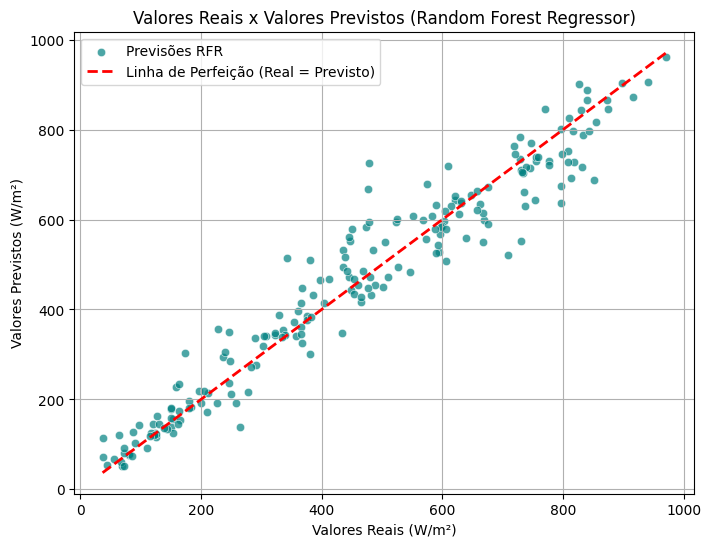

In [140]:
# 1. Comparação de Métricas de Regressão
tabela_metricas_reg = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest Regressor', 'Decision Tree Regressor'],
    'R²': [
        r2_score(y2_test, y_predictLiR),
        r2_score(y2_test, y_predictRFR),
        r2_score(y2_test, y_predictDTR)
    ],
    'MAE (W/m²)': [
        mean_absolute_error(y2_test, y_predictLiR),
        mean_absolute_error(y2_test, y_predictRFR),
        mean_absolute_error(y2_test, y_predictDTR)
    ],
    'MSE ((W/m²)²)': [
        mean_squared_error(y2_test, y_predictLiR),
        mean_squared_error(y2_test, y_predictRFR),
        mean_squared_error(y2_test, y_predictDTR)
    ]
})

display(tabela_metricas_reg)

# 2. Gráfico de Valores Reais x Previstos para o melhor modelo (Random Forest)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y2_test, y=y_predictRFR, alpha=0.7, color='teal', label='Previsões RFR')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], color='red', linestyle='--', lw=2, label='Linha de Perfeição (Real = Previsto)')
plt.title('Valores Reais x Valores Previstos (Random Forest Regressor)')
plt.xlabel('Valores Reais (W/m²)')
plt.ylabel('Valores Previstos (W/m²)')
plt.legend()
plt.grid(True)
plt.show()

### Análise dos Modelos de Regressão e Dinâmica de Energia Solar

#### 1. Interpretação dos Erros dos Modelos de Regressão
Ao avaliarmos as métricas obtidas para os três modelos que buscam estimar a radiação solar ($W/m^2$), observamos comportamentos bem distintos que refletem a complexidade do fenômeno físico:

* **Linear Regression (Regressão Linear):**
  * **$R^2 \approx 0.64$ | MAE $\approx 118.17$ $W/m^2$ | MSE $\approx 22490.22$ $((W/m^2)^2)$**
  * **Análise:** Foi o modelo de menor desempenho. O erro absoluto médio (MAE) de mais de $118$ $W/m^2$ é bastante elevado para uma variável com média de $472$ $W/m^2$. O modelo linear falha porque as variáveis atmosféricas (como umidade e nebulosidade) interagem de forma não-linear. A simples proporcionalidade não é suficiente para explicar o comportamento dinâmico do céu.

* **Decision Tree Regressor (Árvore de Decisão):**
  * **$R^2 \approx 0.87$ | MAE $\approx 61.15$ $W/m^2$ | MSE $\approx 7945.73$ $((W/m^2)^2)$**
  * **Análise:** Representa uma melhora expressiva. Ao criar quebras e regras de decisão, o modelo consegue aprender limites físicos mais abruptos (ex: quando a cobertura de nuvens está próxima de 100%, a radiação despenca). Contudo, por ter estruturas rígidas em escada, tende a gerar predições com pequenas descontinuidades e sofrer de maior variância.

* **Random Forest Regressor (Floresta Aleatória):**
  * **$R^2 \approx 0.94$ | MAE $\approx 44.46$ $W/m^2$ | MSE $\approx 3824.89$ $((W/m^2)^2)$**
  * **Análise:** É o melhor modelo para o problema. Ao combinar múltiplas árvores de decisão independentes (mecanismo de ensemble por bagging), ele reduz drasticamente a variância e suaviza as previsões. Explicar $94\%$ da variabilidade total com um erro absoluto médio de apenas $44.46$ $W/m^2$ demonstra alta confiabilidade para estimar as condições operacionais em tempo real.

---

#### 2. O Peso Físico e Matemático da Variável "Hora"
A variável **hora** é, do ponto de vista físico, um dos preditores mais importantes para modelos de irradiância solar pelas seguintes razões:

1. **A Geometria Solar (Ângulo de Zenit):** A radiação solar que chega a um ponto da Terra depende da inclinação dos raios solares na atmosfera, descrevendo uma curva senoidal clássica ao longo do dia. A variável `hora` atua como um indexador desse ciclo temporal.
2. **Restrição de Contorno:** Ela impõe limites físicos estritos ao modelo. Matematicamente, a hora impede que o modelo preveja valores de radiação altos em períodos crepusculares (como início da manhã às 07:00 ou fim de tarde às 17:00) mesmo que as variáveis como temperatura e umidade estejam altas.
3. **Sazonalidade Térmica:** O comportamento térmico e de umidade do ar responde diretamente ao ciclo do dia, fazendo com que a hora carregue uma correlação indireta forte com a estabilização destas outras variáveis climáticas.

---

#### 3. Por que estimar Radiação não Prevê Automaticamente a Geração Fotovoltaica?
Estimar com sucesso a radiação solar ($W/m^2$) incidente na superfície terrestre é uma condição necessária, mas **não suficiente**, para prever a energia elétrica útil gerada ($kWh$) por um sistema fotovoltaico. Isso ocorre por conta dos seguintes fatores físicos e operacionais:

* **Eficiência Termodinâmica das Células (Limite de Conversão):** Os painéis de silício comerciais convertem apenas de $15\%$ a $22\%$ da energia luminosa recebida em eletricidade. O restante é refletido ou dissipado na forma de calor.
* **Coeficiente de Temperatura:** Células fotovoltaicas perdem eficiência à medida que aquecem. Para cada $1^\circ C$ acima da temperatura padrão de teste ($25^\circ C$), a potência gerada cai de $0,3\%$ a $0,5\%$. Assim, alta radiação associada a temperaturas elevadas pode gerar menos energia do que um cenário de radiação moderada em dia frio.
* **Ângulo de Instalação e Orientação (Fatores de Transposição):** O modelo prevê a radiação no plano horizontal, mas os painéis são instalados inclinados (para otimizar a captação conforme a latitude). Desvios em relação à orientação ótima reduzem a radiação útil captada.
* **Sujidade e Perdas de Sistema (Performance Ratio):** Fatores como poeira acumulada nos painéis, sombreamento parcial (árvores ou prédios vizinhos), perdas na fiação elétrica e a própria ineficiência do inversor ao converter Corrente Contínua (CC) em Corrente Alternada (CA) reduzem em cerca de $15\%$ a $25\%$ a produção final do sistema.

Portanto, para prever a produção de eletricidade real, o dado de radiação gerado por este modelo precisaria ser processado por equações adicionais de física térmica e elétrica que incorporem as características do arranjo fotovoltaico e sua eficiência sob diferentes condições.